In [1]:
from pathlib import Path
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = (Path('..') / 'output' / 'segmentation').resolve()
ATUAL_DIR = BASE_DIR / '2026-05-03_14-37-11'
COMP_DIR = BASE_DIR / '8.final_results' / 'high_res' / '2026-04-28_14-28-44'

def carregar_csvs(pasta, recursivo=False):
    arquivos = sorted(pasta.rglob('*.csv') if recursivo else pasta.glob('*.csv'))
    if not arquivos:
        raise FileNotFoundError(f'Nenhum CSV encontrado em: {pasta}')

    dataframes = []
    for caminho in arquivos:
        df_local = pd.read_csv(caminho)
        df_local['source_file'] = caminho.name
        dataframes.append(df_local)

    return pd.concat(dataframes, ignore_index=True), arquivos

## 1) Carregamento dos dados
Importa bibliotecas, define caminhos e prepara funcao de leitura dos CSVs.

In [2]:
df_all, csv_files = carregar_csvs(ATUAL_DIR, recursivo=False)

print(f'Pasta atual: {ATUAL_DIR}')
print(f'CSV encontrados: {len(csv_files)}')
print(f'Total de linhas consolidadas: {len(df_all)}')

df_all.head()

Pasta atual: /home/matheus/workspace/coronary-centerline-detection/output/segmentation/2026-05-03_14-37-11
CSV encontrados: 4
Total de linhas consolidadas: 560


,IMG_ID,dice_artery,artery_voxels,ostia_found,ostia_status,segmentation_attempted,proceeded_with_bad_ostia,skip_reason,ostia_error,both_correct,...,right_dist_mm,ostia_left,ostia_right,error,status,downscale_method,opencv_interpolation,downscale_factors,max_threshold_percentile,source_file
0,568,0.257189,343479.0,True,found_but_wrong,True,True,NaN,NaN,False,...,0.000000,"(98, 244, 174)","(184, 160, 166)",NaN,um correto,scipy,NaN,"(1, 1, 1)",99.7,ostios_test_lote_1_summary.csv
1,762,0.527580,156160.0,True,both_correct,True,False,NaN,NaN,True,...,0.000000,"(192, 339, 182)","(232, 259, 208)",NaN,ambos corretos,scipy,NaN,"(1, 1, 1)",99.7,ostios_test_lote_1_summary.csv
2,765,0.544584,160994.0,True,both_tolerable,True,False,NaN,NaN,False,...,0.000000,"(202, 324, 173)","(255, 251, 209)",NaN,ambos toleráveis,scipy,NaN,"(1, 1, 1)",99.7,ostios_test_lote_1_summary.csv
3,693,0.612487,177419.0,True,both_tolerable,True,False,NaN,NaN,False,...,0.000000,"(196, 332, 148)","(241, 252, 178)",NaN,ambos toleráveis,scipy,NaN,"(1, 1, 1)",99.7,ostios_test_lote_1_summary.csv
4,469,0.082360,21154.0,True,found_but_wrong,True,True,NaN,NaN,False,...,13.186167,"(195, 352, 129)","(256, 287, 132)",NaN,nenhum correto,scipy,NaN,"(1, 1, 1)",99.7,ostios_test_lote_1_summary.csv


In [3]:
if 'dice_artery' not in df_all.columns:
    raise KeyError('Coluna dice_artery nao encontrada nos CSVs.')

df_all['dice_artery'] = pd.to_numeric(df_all['dice_artery'], errors='coerce')
df_valid = df_all.dropna(subset=['dice_artery']).copy()

dice_por_csv = (
    df_valid.groupby('source_file', as_index=False)['dice_artery']
    .mean()
    .rename(columns={'dice_artery': 'dice_medio'})
    .sort_values('source_file')
)

dice_agregado = df_valid['dice_artery'].mean()

print('Dice medio por CSV:')
display(dice_por_csv)

print(f'Dice agregado (todos os CSV juntos): {dice_agregado:.6f}')

Dice medio por CSV:


,source_file,dice_medio
0,ostios_test_lote_1_summary.csv,0.498501
1,ostios_test_lote_2_summary.csv,0.500296
2,ostios_test_lote_3_summary.csv,0.464840
3,ostios_test_lote_4_summary.csv,0.479767


Dice agregado (todos os CSV juntos): 0.485851


## 3) Qualidade de ostios (conjunto atual)
Resumo percentual de casos corretos/toleraveis versus errados.

In [4]:
if 'status' not in df_all.columns:
    raise KeyError('Coluna status nao encontrada nos CSVs.')

def normalizar_txt(txt):
    txt = str(txt).strip().lower()
    txt = unicodedata.normalize('NFD', txt)
    return ''.join(ch for ch in txt if unicodedata.category(ch) != 'Mn')

status_norm = df_all['status'].fillna('').map(normalizar_txt)
status_correto = {'ambos corretos', 'ambos toleraveis'}

resultado_ostio = status_norm.apply(
    lambda s: 'Corretos/Toleraveis' if s in status_correto else 'Errados'
)

contagem = resultado_ostio.value_counts().reindex(['Corretos/Toleraveis', 'Errados'], fill_value=0)
total = contagem.sum()

percentuais = (contagem / total * 100).round(2)
resumo_ostio = pd.DataFrame({
    'qtd': contagem,
    'percentual': percentuais,
})

print('Resumo de ostios (corretos/toleraveis vs errados):')
display(resumo_ostio)

Resumo de ostios (corretos/toleraveis vs errados):


,qtd,percentual
status,,
Corretos/Toleraveis,406,72.5
Errados,154,27.5


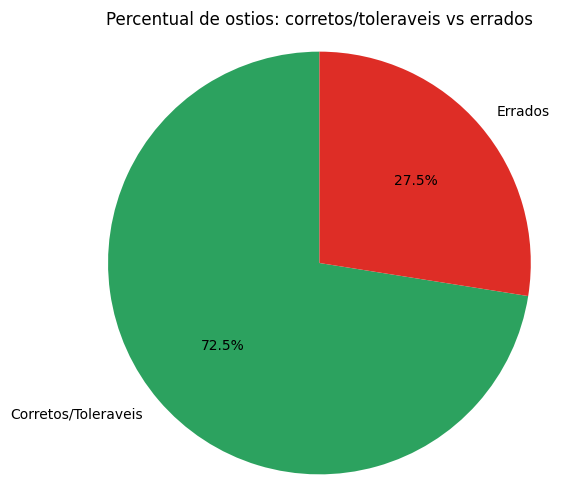

In [5]:
plt.figure(figsize=(6, 6))
plt.pie(
    resumo_ostio['qtd'],
    labels=resumo_ostio.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ca25f', '#de2d26'],
)
plt.title('Percentual de ostios: corretos/toleraveis vs errados')
plt.axis('equal')
plt.show()

## 4) Carregamento do conjunto de comparacao
Leitura dos CSVs de 2026-04-28_14-28-44 para comparar com o conjunto atual.

In [6]:
df_all_comp, comp_csv_files = carregar_csvs(COMP_DIR, recursivo=True)

for col in ['IMG_ID', 'dice_artery']:
    if col not in df_all_comp.columns:
        raise KeyError(f'Coluna {col} nao encontrada nos CSVs de comparacao.')

df_all_comp['IMG_ID'] = pd.to_numeric(df_all_comp['IMG_ID'], errors='coerce')
df_all_comp['dice_artery'] = pd.to_numeric(df_all_comp['dice_artery'], errors='coerce')

df_comp_valid = df_all_comp.dropna(subset=['IMG_ID', 'dice_artery']).copy()
df_comp_valid['IMG_ID'] = df_comp_valid['IMG_ID'].astype(int)

print(f'Pasta comparada: {COMP_DIR}')
print(f'CSV de comparacao encontrados: {len(comp_csv_files)}')
print(f'Linhas validas de comparacao: {len(df_comp_valid)}')

Pasta comparada: /home/matheus/workspace/coronary-centerline-detection/output/segmentation/8.final_results/high_res/2026-04-28_14-28-44
CSV de comparacao encontrados: 1
Linhas validas de comparacao: 700


## 5) Casos comuns entre os dois conjuntos
Mantem apenas IMG_ID presentes em ambos os datasets.

In [7]:
for col in ['IMG_ID', 'dice_artery']:
    if col not in df_valid.columns:
        raise KeyError(f'Coluna {col} nao encontrada nos CSVs atuais.')

df_valid['IMG_ID'] = pd.to_numeric(df_valid['IMG_ID'], errors='coerce')
df_valid_base = df_valid.dropna(subset=['IMG_ID', 'dice_artery']).copy()
df_valid_base['IMG_ID'] = df_valid_base['IMG_ID'].astype(int)

dice_atual = (
    df_valid_base.groupby('IMG_ID', as_index=False)['dice_artery']
    .mean()
    .rename(columns={'dice_artery': 'dice_atual'})
)

dice_comparacao = (
    df_comp_valid.groupby('IMG_ID', as_index=False)['dice_artery']
    .mean()
    .rename(columns={'dice_artery': 'dice_comparacao'})
)

casos_comuns = (
    dice_atual.merge(dice_comparacao, on='IMG_ID', how='inner')
    .sort_values('IMG_ID')
    .reset_index(drop=True)
)

print(f'Quantidade de IMG_ID em comum: {len(casos_comuns)}')
display(casos_comuns.head())

Quantidade de IMG_ID em comum: 560


,IMG_ID,dice_atual,dice_comparacao
0,1,0.655246,0.655246
1,3,0.625120,0.625120
2,4,0.508605,0.508605
3,5,0.505317,0.505317
4,8,0.204358,0.204358


## 6) Dice score medio dos casos comuns
Calcula o Dice medio somente para os IMG_ID que existem em ambos os conjuntos.

In [8]:
resumo_dice_comum = pd.DataFrame([
    {
        'dataset': 'Atual (somente IDs comuns)',
        'n_img_id': len(casos_comuns),
        'dice_medio': casos_comuns['dice_atual'].mean(),
    },
    {
        'dataset': 'Comparacao (somente IDs comuns)',
        'n_img_id': len(casos_comuns),
        'dice_medio': casos_comuns['dice_comparacao'].mean(),
    },
])

print('Dice score medio nos casos comuns:')
display(resumo_dice_comum)

Dice score medio nos casos comuns:


,dataset,n_img_id,dice_medio
0,Atual (somente IDs comuns),560,0.485851
1,Comparacao (somente IDs comuns),560,0.471347


## 7) Comparacao de ostios acertados (casos comuns)
Considera como acertado: status em ambos corretos ou ambos toleraveis.

In [9]:
def normalizar_status(txt):
    txt = str(txt).strip().lower()
    txt = unicodedata.normalize('NFD', txt)
    return ''.join(ch for ch in txt if unicodedata.category(ch) != 'Mn')

status_alvo = {'ambos corretos', 'ambos toleraveis'}

base_status_atual = df_all[['IMG_ID', 'status']].copy()
base_status_comp = df_all_comp[['IMG_ID', 'status']].copy()

base_status_atual['IMG_ID'] = pd.to_numeric(base_status_atual['IMG_ID'], errors='coerce')
base_status_comp['IMG_ID'] = pd.to_numeric(base_status_comp['IMG_ID'], errors='coerce')

base_status_atual = base_status_atual.dropna(subset=['IMG_ID']).copy()
base_status_comp = base_status_comp.dropna(subset=['IMG_ID']).copy()

base_status_atual['IMG_ID'] = base_status_atual['IMG_ID'].astype(int)
base_status_comp['IMG_ID'] = base_status_comp['IMG_ID'].astype(int)

base_status_atual = base_status_atual[base_status_atual['IMG_ID'].isin(casos_comuns['IMG_ID'])]
base_status_comp = base_status_comp[base_status_comp['IMG_ID'].isin(casos_comuns['IMG_ID'])]

status_atual_por_id = (
    base_status_atual.groupby('IMG_ID')['status']
    .first()
    .map(normalizar_status)
    .reset_index(name='status_norm')
)
status_comp_por_id = (
    base_status_comp.groupby('IMG_ID')['status']
    .first()
    .map(normalizar_status)
    .reset_index(name='status_norm')
)

acerto_atual = status_atual_por_id['status_norm'].isin(status_alvo)
acerto_comp = status_comp_por_id['status_norm'].isin(status_alvo)

resumo_ostio_comum = pd.DataFrame([
    {
        'dataset': 'Atual (IDs comuns)',
        'n_img_id': len(status_atual_por_id),
        'ostios_acertados_qtd': int(acerto_atual.sum()),
        'ostios_acertados_percentual': round(float(acerto_atual.mean() * 100), 2),
    },
    {
        'dataset': 'Comparacao (IDs comuns)',
        'n_img_id': len(status_comp_por_id),
        'ostios_acertados_qtd': int(acerto_comp.sum()),
        'ostios_acertados_percentual': round(float(acerto_comp.mean() * 100), 2),
    },
])

print('Comparacao de ostios acertados nos casos comuns:')
display(resumo_ostio_comum)

Comparacao de ostios acertados nos casos comuns:


,dataset,n_img_id,ostios_acertados_qtd,ostios_acertados_percentual
0,Atual (IDs comuns),560,406,72.50
1,Comparacao (IDs comuns),560,401,71.61
